✅ CIFAR-100 subset loaded: (5000, 3072)
✅ Models built. Running evaluations...
🔍 Evaluating Brute Force...
🔍 Evaluating LSH...
🔍 Evaluating Annoy...
🔍 Evaluating KD-Tree...
🔍 Evaluating Ball-Tree...
🔍 Evaluating HNSW...


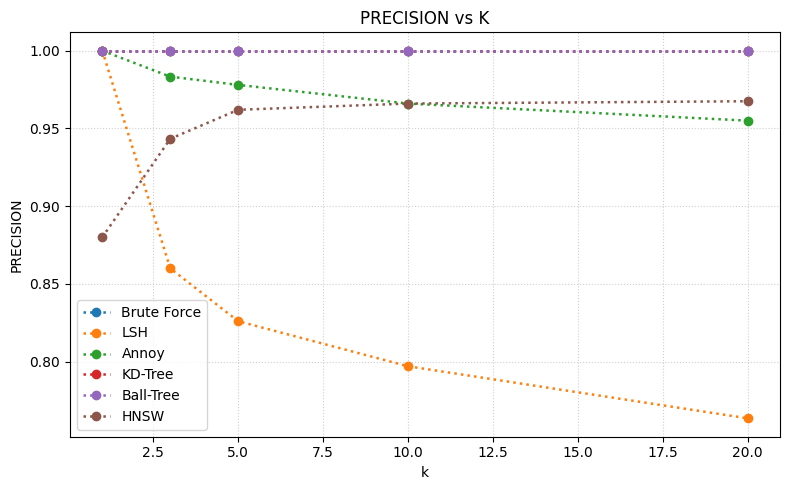

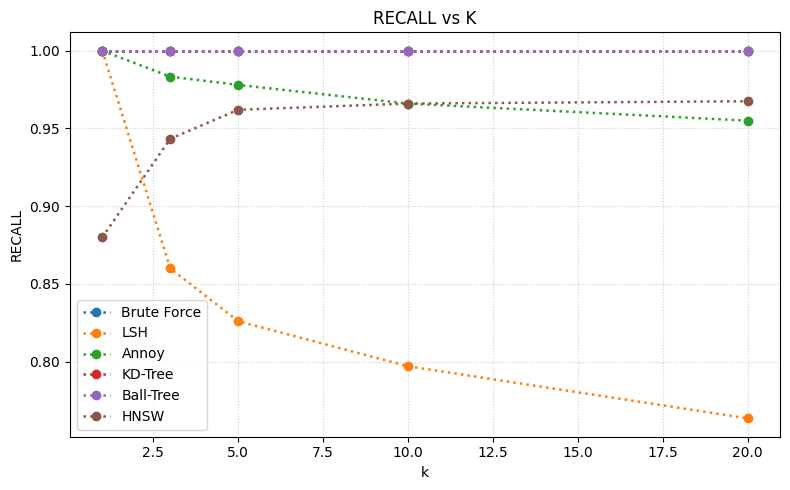

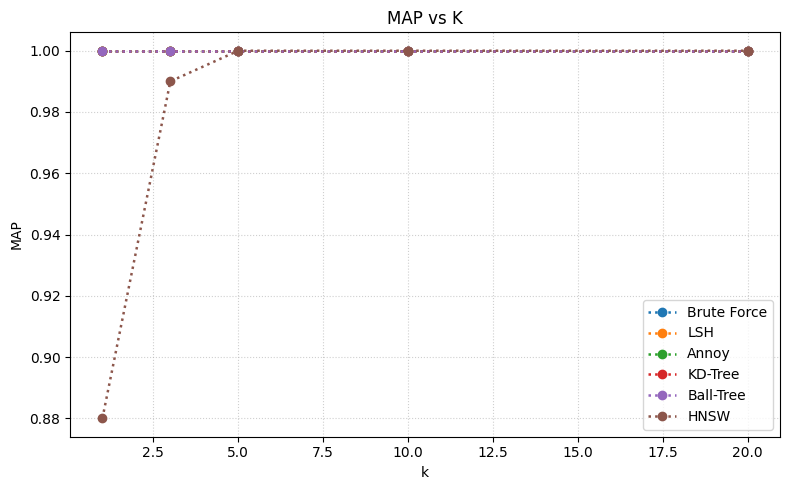

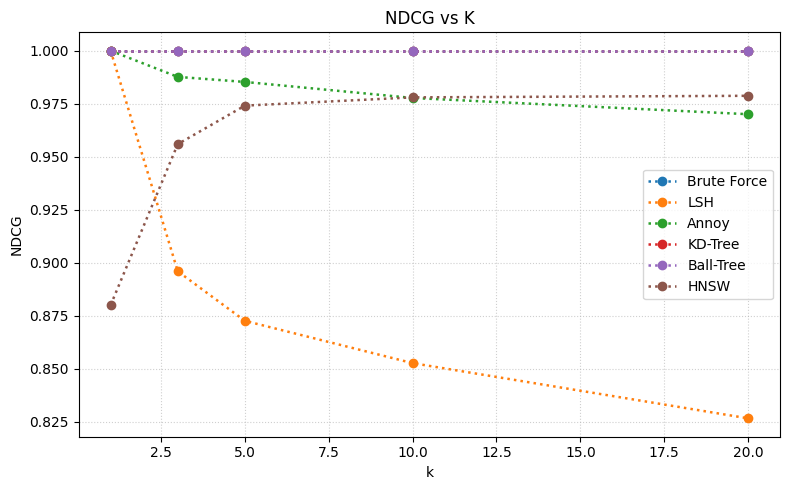

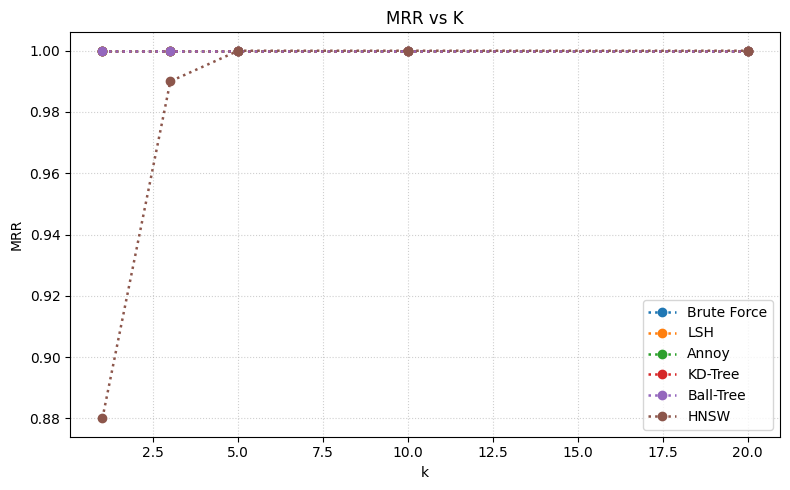

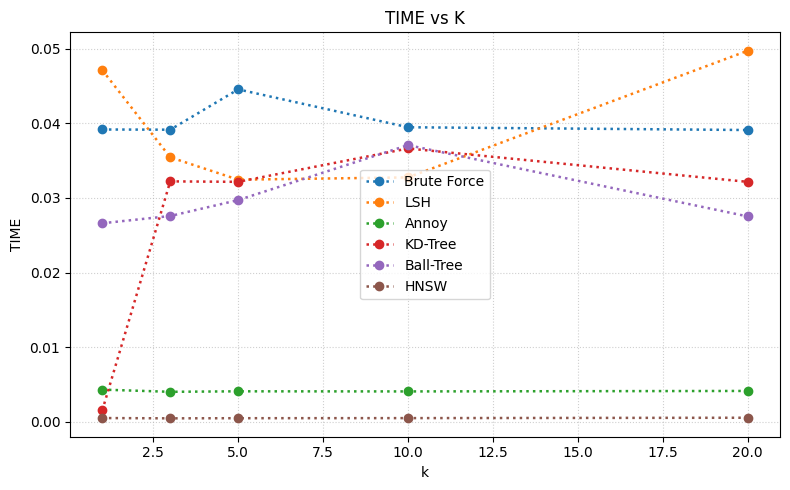


📈 Annoy: metrics vs num_trees


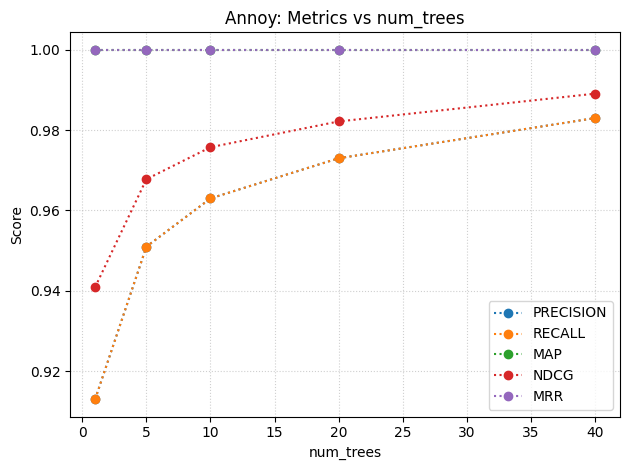


📈 HNSW: metrics vs ef_construction


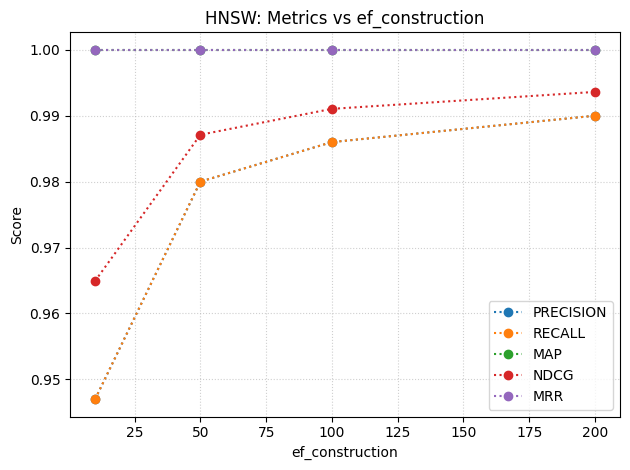


📈 LSH: metrics vs num_tables


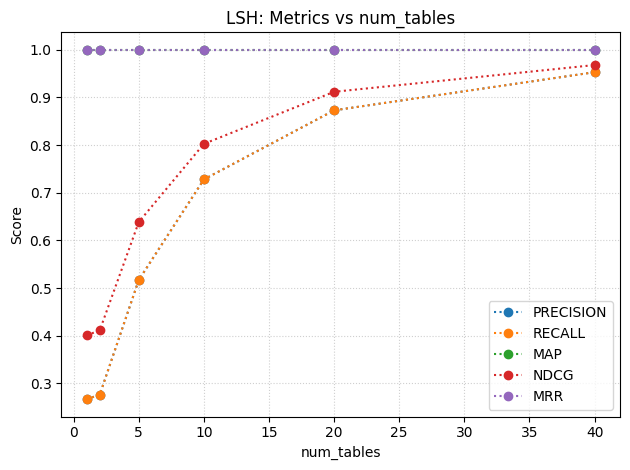


📈 KD-Tree: metrics vs leaf_size


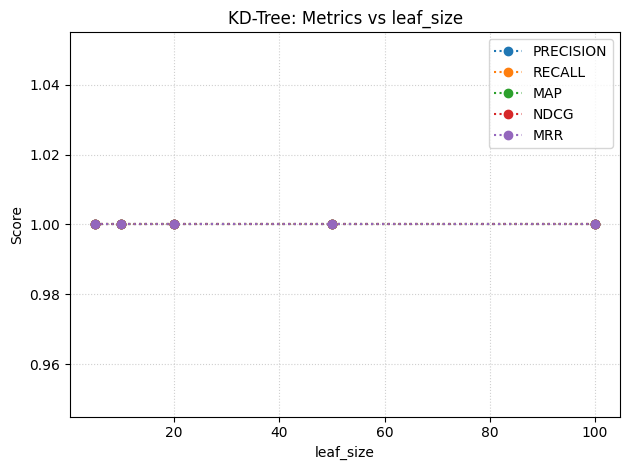


📈 Ball-Tree: metrics vs leaf_size


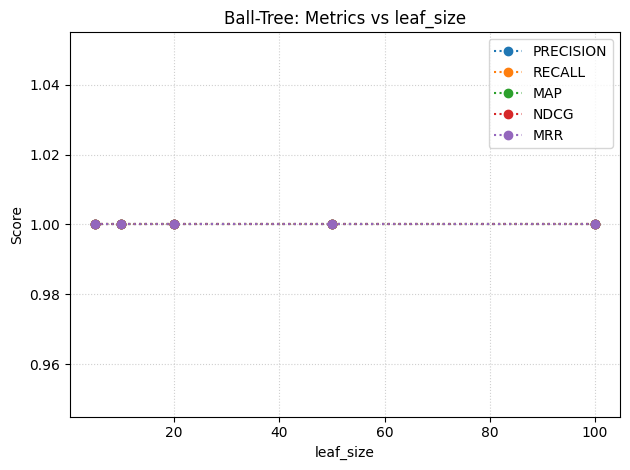

In [10]:
#loading cifar dataset
import torch
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import defaultdict
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import euclidean_distances
from annoy import AnnoyIndex
import hnswlib

def load_cifar100_rgb(subset_size=5000):
    transform = transforms.Compose([transforms.ToTensor()])
    dataset = datasets.CIFAR100(root="./data", train=True, download=True, transform=transform)
    X = []
    for i in range(subset_size):
        img, _ = dataset[i]
        X.append(img.view(-1).numpy())  # flatten 3×32×32 → 3072
    X_np = np.stack(X).astype(np.float32)
    print(f" CIFAR-100 subset loaded:")
    return X_np


#defining all algorithms
def build_brute_force(X):
    m = NearestNeighbors(algorithm='brute', metric='euclidean')
    m.fit(X)
    return m

class SimpleLSH:
    def __init__(self, dim, num_tables=5, num_hashes=10):
        self.dim, self.num_tables, self.num_hashes = dim, num_tables, num_hashes
        self.hash_tables = [defaultdict(list) for _ in range(num_tables)]
        self.hyperplanes = [np.random.randn(num_hashes, dim) for _ in range(num_tables)]
    def _hash(self, v, t):
        p = np.dot(self.hyperplanes[t], v)
        return ''.join(['1' if x > 0 else '0' for x in p])
    def add_items(self, X):
        for i, v in enumerate(X):
            for t in range(self.num_tables):
                self.hash_tables[t][self._hash(v, t)].append(i)
    def query(self, q, X, num_candidates=200):
        c = set()
        for t in range(self.num_tables):
            c.update(self.hash_tables[t].get(self._hash(q, t), []))
        if not c: return []
        c = list(c)
        d = euclidean_distances([q], [X[i] for i in c])[0]
        return [c[i] for i in np.argsort(d)]
def build_lsh(X, num_tables=10, num_hashes=16):
    l = SimpleLSH(X.shape[1], num_tables, num_hashes)
    l.add_items(X)
    return l

def build_annoy(X, num_trees=10):
    f = X.shape[1]
    a = AnnoyIndex(f, 'euclidean')
    for i, v in enumerate(X):
        a.add_item(i, v.tolist())
    a.build(num_trees)
    return a

def build_kdtree(X, leaf_size=40):
    m = NearestNeighbors(algorithm='kd_tree', leaf_size=leaf_size)
    m.fit(X)
    return m

def build_balltree(X, leaf_size=40):
    m = NearestNeighbors(algorithm='ball_tree', leaf_size=leaf_size)
    m.fit(X)
    return m

def build_hnsw(X, space='l2', M=16, ef_construction=200):
    p = hnswlib.Index(space=space, dim=X.shape[1])
    p.init_index(max_elements=len(X), ef_construction=ef_construction, M=M)
    p.add_items(X)
    p.set_ef(50)
    return p

#def build_knn(X, n_neighbors=10):
   # m = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
    #m.fit(X)
    #return m


#defining all metrics
def precision_k(true, retrieved, k): return len(set(true[:k]) & set(retrieved[:k])) / k
def recall_k(true, retrieved, k): return len(set(true[:k]) & set(retrieved[:k])) / len(true[:k])
def ap_k(true, retrieved, k):
    h, s = 0, 0
    for i, idx in enumerate(retrieved[:k], 1):
        if idx in true[:k]:
            h += 1; s += h / i
    return s / h if h else 0
def ndcg_k(true, retrieved, k):
    dcg = sum((1 if idx in true[:k] else 0) / np.log2(i + 2) for i, idx in enumerate(retrieved[:k]))
    idcg = sum(1 / np.log2(i + 2) for i in range(min(k, len(true))))
    return dcg / idcg if idcg > 0 else 0
def mrr_k(true, retrieved, k):
    for i, idx in enumerate(retrieved[:k], 1):
        if idx in true[:k]: return 1 / i
    return 0


#defining evaluations vs k
def evaluate_vs_k(algorithms, X, k_values=[1,3,5,10,20], num_queries=100):
    qidx = np.random.choice(len(X), num_queries, replace=False)
    bf = algorithms["Brute Force"]
    truth = {}
    for q in qidx:
        _, idx = bf.kneighbors([X[q]], n_neighbors=max(k_values))
        truth[q] = idx[0]

    results = {name: defaultdict(list) for name in algorithms.keys()}

    for name, model in algorithms.items():

        for k in k_values:
            p_list, r_list, m_list, n_list, mr_list, t_list = [], [], [], [], [], []
            for q in qidx:
                start = time.time()
                if name in ["KD-Tree","Ball-Tree"]:
                    _, idx = model.kneighbors([X[q]], n_neighbors=k); idx = idx[0]
                elif name == "Annoy": idx = model.get_nns_by_vector(X[q], k)
                elif name == "LSH": idx = model.query(X[q], X)[:k]
                elif name == "HNSW": lbl, _ = model.knn_query(X[q], k=k); idx = lbl[0]
                elif name == "Brute Force":
                    _, idx = bf.kneighbors([X[q]], n_neighbors=k); idx = idx[0]
                elapsed = time.time() - start
                gt = truth[q]
                p_list.append(precision_k(gt, idx, k))
                r_list.append(recall_k(gt, idx, k))
                m_list.append(ap_k(gt, idx, k))
                n_list.append(ndcg_k(gt, idx, k))
                mr_list.append(mrr_k(gt, idx, k))
                t_list.append(elapsed)
            results[name]['precision'].append(np.mean(p_list))
            results[name]['recall'].append(np.mean(r_list))
            results[name]['map'].append(np.mean(m_list))
            results[name]['ndcg'].append(np.mean(n_list))
            results[name]['mrr'].append(np.mean(mr_list))
            results[name]['time'].append(np.mean(t_list))
    return results

#plotting metrics vs k
def plot_metrics_vs_k(results_vs_k, k_values):
    metrics = ['precision', 'recall', 'map', 'ndcg', 'mrr', 'time']
    for m in metrics:
        plt.figure(figsize=(8,5))
        for algo, res in results_vs_k.items():
            plt.plot(k_values, res[m], marker='o', linewidth=1.8, label=algo,ls= ':')
        plt.title(f"{m.upper()} vs K")
        plt.xlabel("k"); plt.ylabel(m.upper())
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()


#evaluating vs parameters
def evaluate_vs_param(X, algo_name, build_func, param_name, param_values, k=10, num_queries=100):

    metrics = defaultdict(list)
    qidx = np.random.choice(len(X), num_queries, replace=False)
    bf = build_brute_force(X)
    truth = {q: bf.kneighbors([X[q]], n_neighbors=k)[1][0] for q in qidx}

    for v in param_values:
        if algo_name=="Annoy": m=build_func(X,num_trees=v)
        elif algo_name=="HNSW": m=build_func(X,ef_construction=v)
        elif algo_name=="LSH": m=build_func(X,num_tables=v)
        elif algo_name in ["KD-Tree","Ball-Tree"]: m=build_func(X,leaf_size=v)
        #elif algo_name=="kNN": m=build_func(X,n_neighbors=v)
        else: m=build_func(X)
        p,r,mp,n,mr,t=[],[],[],[],[],[]
        for q in qidx:
            start=time.time()
            if algo_name in ["KD-Tree","Ball-Tree"]:
                _,idx=m.kneighbors([X[q]],n_neighbors=k); idx=idx[0]
            elif algo_name=="Annoy": idx=m.get_nns_by_vector(X[q],k)
            elif algo_name=="LSH": idx=m.query(X[q],X)[:k]
            elif algo_name=="HNSW": lbl,_=m.knn_query(X[q],k=k); idx=lbl[0]
            elapsed=time.time()-start
            gt=truth[q]
            p.append(precision_k(gt,idx,k)); r.append(recall_k(gt,idx,k))
            mp.append(ap_k(gt,idx,k)); n.append(ndcg_k(gt,idx,k)); mr.append(mrr_k(gt,idx,k))
            t.append(elapsed)
        metrics['precision'].append(np.mean(p)); metrics['recall'].append(np.mean(r))
        metrics['map'].append(np.mean(mp)); metrics['ndcg'].append(np.mean(n))
        metrics['mrr'].append(np.mean(mr)); metrics['time'].append(np.mean(t))

    for mname in ['precision','recall','map','ndcg','mrr']:
    plt.plot(param_values, metrics[mname], marker='o', label=mname.upper(),ls= ':')
    plt.title(f"{algo_name}: Metrics vs {param_name}")
    plt.xlabel(param_name); plt.ylabel("Score"); plt.legend(); plt.grid(True, ls=':', alpha=0.6)
    plt.tight_layout(); plt.show()


#plotting evaluations vs parameters
if __name__ == "__main__":
    X = load_cifar100_rgb(subset_size=5000)
    algorithms = {
        "Brute Force": build_brute_force(X),
        "LSH": build_lsh(X),
        "Annoy": build_annoy(X, 10),
        "KD-Tree": build_kdtree(X),
        "Ball-Tree": build_balltree(X),
        "HNSW": build_hnsw(X, M=8, ef_construction=100),
        #"kNN": build_knn(X)
    }


    k_values = [1,3,5,10,20]
    results_vs_k = evaluate_vs_k(algorithms, X, k_values=k_values, num_queries=100)
    plot_metrics_vs_k(results_vs_k, k_values)

    evaluate_vs_param(X, "Annoy", build_annoy, "num_trees", [1,5,10,20,40], k=10)
    evaluate_vs_param(X, "HNSW", build_hnsw, "ef_construction", [10,50,100,200], k=10)
    evaluate_vs_param(X, "LSH", build_lsh, "num_tables", [1,2,5,10,20,40], k=10)
    evaluate_vs_param(X, "KD-Tree", build_kdtree, "leaf_size", [5,10,20,50,100], k=10)
    evaluate_vs_param(X, "Ball-Tree", build_balltree, "leaf_size", [5,10,20,50,100], k=10)
   # evaluate_vs_param(X, "kNN", build_knn, "n_neighbors", [1,3,5,10,20], k=10)


🖼️ Query index: 1159


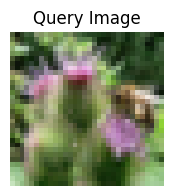


🔹 Brute Force: Top-10 retrieved results


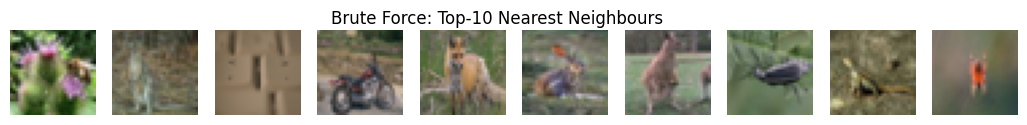


🔹 LSH: Top-10 retrieved results


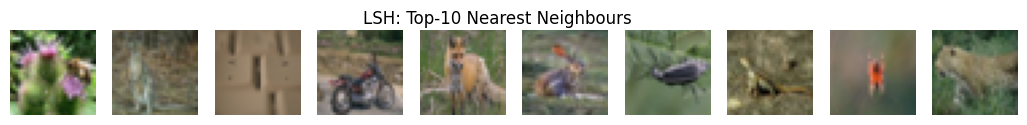


🔹 Annoy: Top-10 retrieved results


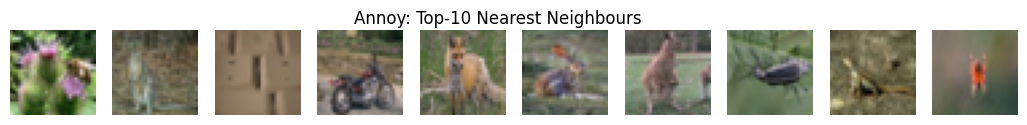


🔹 KD-Tree: Top-10 retrieved results


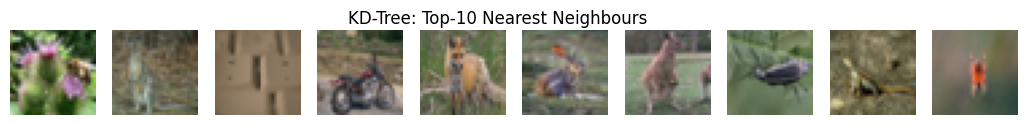


🔹 Ball-Tree: Top-10 retrieved results


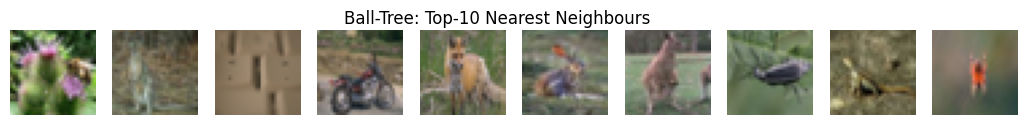


🔹 HNSW: Top-10 retrieved results


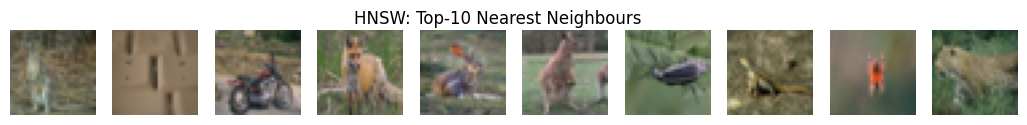

In [11]:
# ============================================================
# 🔍 8️⃣ VISUALISE QUERY vs RETRIEVED IMAGES (k = 10)
# ============================================================
from torchvision.utils import make_grid

def show_query_results(X, dataset, algorithms, k=10, query_index=None):
    """
    Displays query image (left) and top-k retrieved images (right)
    for each algorithm.
    """
    if query_index is None:
        query_index = np.random.randint(0, len(X))
    print(f"\n🖼️ Query index: {query_index}")

    query_vec = X[query_index]

    # Reconstruct the query image from flattened RGB
    query_img = torch.tensor(query_vec).view(3, 32, 32).permute(1, 2, 0)

    # Display query image
    plt.figure(figsize=(2, 2))
    plt.imshow(query_img)
    plt.axis("off")
    plt.title("Query Image")
    plt.show()

    # Evaluate for each algorithm
    for name, model in algorithms.items():
        print(f"\n🔹 {name}: Top-{k} retrieved results")

        # Run the query
        if name in ["KD-Tree", "Ball-Tree"]:
            _, idx = model.kneighbors([query_vec], n_neighbors=k)
            idx = idx[0]
        elif name == "Annoy":
            idx = model.get_nns_by_vector(query_vec, k)
        elif name == "LSH":
            idx = model.query(query_vec, X)[:k]
        elif name == "HNSW":
            lbl, _ = model.knn_query(query_vec, k=k)
            idx = lbl[0]
        elif name == "Brute Force":
            _, idx = model.kneighbors([query_vec], n_neighbors=k)
            idx = idx[0]
        else:
            continue

        # Retrieve top-k images
        retrieved_imgs = []
        for i in idx:
            img = torch.tensor(X[i]).view(3, 32, 32).permute(1, 2, 0)
            retrieved_imgs.append(img)

        # Display retrieved images
        fig, axes = plt.subplots(1, k, figsize=(k * 1.3, 1.3))
        for j, ax in enumerate(axes):
            ax.imshow(retrieved_imgs[j])
            ax.axis("off")
        plt.suptitle(f"{name}: Top-{k} Nearest Neighbours", fontsize=12)
        plt.show()


# ============================================================
# 🚀 RUN VISUALIZATION
# ============================================================
# Reload CIFAR100 with labels for image reconstruction
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.CIFAR100(root="./data", train=True, download=False, transform=transform)

# Pick a random sample or set a specific one, e.g., query_index=25
show_query_results(X, dataset, algorithms, k=10, query_index=None)
